# FlashEats pipeline — guided walkthrough

The same code as `python run_pipeline.py`, run **stage by stage** so each FDE decision is visible with its evidence:

`policy file → ingest (SQL · API · CSV · JSON · external weather) → raw preservation → profile → clean → business rules → workflow model → metrics → decision layer → gate`

It writes to `notebooks/walkthrough_run/` so it never overwrites the published evidence in `output/`.

In [1]:
import sys, json, time
from pathlib import Path
import pandas as pd
ROOT = Path.cwd()
while not (ROOT / "source_systems").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from flasheats_pipeline.config import load_config
from flasheats_pipeline.logging_utils import configure_logging
from flasheats_pipeline.ingest import SqlSource, DispatchApiClient, ObservedWeatherClient, read_csv_source, read_json_source, flatten_driver_events
from flasheats_pipeline.pipeline import FILE_SOURCES, MockApiProcess
from flasheats_pipeline.profiling import profile_all
from flasheats_pipeline.cleaning import standardise
from flasheats_pipeline.rules import run_rules, results_frame
from flasheats_pipeline.model import build_model
from flasheats_pipeline.metrics import compute_metrics
from flasheats_pipeline.insights import compute_insights
from flasheats_pipeline.monitoring import build_ledger
from flasheats_pipeline.gate import build_gate
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 170); pd.set_option("display.max_colwidth", 80)
work = ROOT / "notebooks" / "walkthrough_run"
cfg = load_config(ROOT / "config" / "pipeline.yaml", run_id="walkthrough", data_dir=work / "data", output_dir=work / "output")
configure_logging(None)
print("policy file:", cfg.config_file)
print({k: getattr(cfg, k) for k in ["late_threshold_min", "meaningful_late_threshold_min", "status_freshness_sla_min", "ew_min_precision", "target_on_time_rate_pct"]})

policy file: B:\Trimester-9\FDE\assignment-2\config\pipeline.yaml
{'late_threshold_min': 0, 'meaningful_late_threshold_min': 10, 'status_freshness_sla_min': 15, 'ew_min_precision': 0.9, 'target_on_time_rate_pct': 80}


## 1 · Ingest — four client systems and one independent source
Each retrieval preserves its raw input under `walkthrough_run/data/raw/walkthrough/` with a SHA-256.

In [2]:
raw, ingestion = {}, {}
sql = SqlSource(cfg.db_path, cfg.sql_dir, cfg.raw_dir)
for name, table in [("orders_extract", "orders"), ("restaurants_extract", "restaurants"), ("drivers_extract", "drivers"), ("customers_extract", "customers")]:
    raw[table] = sql.extract(name, table, {"start_at": None, "end_at": None} if table == "orders" else None)
for name, (fname, required, optional) in FILE_SOURCES.items():
    raw[name], _ = read_csv_source(cfg.files_dir / fname, name, required, cfg.raw_dir)
obj, res = read_json_source(cfg.files_dir / "driver_events.json", "driver_events", cfg.raw_dir)
raw["driver_events"] = flatten_driver_events(obj, res)
with MockApiProcess(cfg.mock_api_script, cfg.api_base_url):
    records, api_report = DispatchApiClient(cfg.api_base_url, cfg.raw_dir, page_size=cfg.api_page_size, backoff_base_s=0.2).fetch_all()
raw["dispatch"] = pd.DataFrame(records, dtype="object")
ingestion["dispatch_api"] = api_report.as_dict()
wx, wrep = ObservedWeatherClient(cfg.weather_base_url, cfg.weather_latitude, cfg.weather_longitude, cfg.source_timezone, cfg.raw_dir,
                                 cache_dir=ROOT / "data" / "external").fetch("2026-08-01", "2026-08-29")
ingestion["external_weather"] = wrep.as_dict()
if wx is not None:
    raw["weather_obs"] = wx
print(f"API complete={api_report.complete} records={api_report.records_fetched}/{api_report.expected_total} pages={api_report.pages_fetched} retries={api_report.retries}")
print(f"weather mode={wrep.mode} hours={wrep.hours}")
display(pd.DataFrame({k: [len(v)] for k, v in raw.items()}, index=["rows"]).T)

2026-09-27 22:29:20 | INFO    | SQL extract orders_extract         table=orders       rows= 1603 cols=13 -> orders_extract.csv


2026-09-27 22:29:20 | INFO    | SQL extract restaurants_extract    table=restaurants  rows=   60 cols=6 -> restaurants_extract.csv


2026-09-27 22:29:21 | INFO    | SQL extract drivers_extract        table=drivers      rows=  120 cols=4 -> drivers_extract.csv


2026-09-27 22:29:21 | INFO    | SQL extract customers_extract      table=customers    rows=  900 cols=3 -> customers_extract.csv


2026-09-27 22:29:21 | INFO    | CSV  tickets                rows=  202 cols= 5 malformed=0 extra=['customer_message'] sha256=ee2f43a9d69e


...

2026-09-27 22:29:26 | INFO    | API ingestion COMPLETE: pages=16 records=1600 unique=1600 expected=1600 retries=2


2026-09-27 22:29:26 | INFO    | Stopped mock Dispatch API


2026-09-27 22:29:30 | INFO    | weather live: 696 hourly observations 2026-08-01T00:00:00 -> 2026-08-29T23:00:00, retries=0


API complete=True records=1600/1600 pages=16 retries=2
weather mode=live hours=696


,rows
orders,1603
restaurants,60
drivers,120
customers,900
tickets,202
restaurant_status,502
app_actions,2365
interventions,430
order_outcomes_ref,1600
driver_events,10035


## 2 · Profile before cleaning

In [3]:
ref = raw.pop("order_outcomes_ref")
profiles = profile_all({k: (v, {"orders": "order_id", "tickets": "ticket_id", "dispatch": "order_id"}.get(k)) for k, v in raw.items()})
display(pd.DataFrame([{"dataset": p.name, "rows": p.rows, "duplicate_key_rows": p.duplicate_key_rows, "exact_duplicates": p.exact_duplicate_rows, "notes": "; ".join(p.notes)[:120]} for p in profiles]))

,dataset,rows,duplicate_key_rows,exact_duplicates,notes
0,orders,1603,3,0,3 rows share an existing order_id (grain is not one row per order_id)
1,restaurants,60,0,0,
2,drivers,120,0,0,
3,customers,900,0,0,
4,tickets,202,1,1,1 rows share an existing ticket_id (grain is not one row per ticket_id); 1 r...
5,restaurant_status,502,0,2,2 rows are exact duplicates
6,app_actions,2365,0,0,
7,interventions,430,0,0,
8,driver_events,10035,0,0,
9,dispatch,1600,0,0,


## 3 · Clean — representation only, every change logged, nothing silently lost

In [4]:
clean, rep = standardise(raw, cfg)
display(rep.actions_frame())
print("unexpected categories kept + flagged:", rep.unexpected_categories)
ledger, ledger_checks = build_ledger(rep)
display(ledger)

2026-09-27 22:29:31 | INFO    | clean orders           raw= 1603 -> clean= 1600


2026-09-27 22:29:31 | INFO    | clean restaurants      raw=   60 -> clean=   60


2026-09-27 22:29:31 | INFO    | clean drivers          raw=  120 -> clean=  120


2026-09-27 22:29:31 | INFO    | clean customers        raw=  900 -> clean=  900


2026-09-27 22:29:31 | INFO    | clean tickets          raw=  202 -> clean=  201


...

2026-09-27 22:29:32 | WARNING |   unexpected categories in tickets.category: {'eta_issue': 1} (retained + flagged)


2026-09-27 22:29:32 | WARNING |   unexpected categories in restaurant_status.status: {'handoff': 1} (retained + flagged)


,dataset,column,action,count,detail
0,orders,final_status,"normalise_category (trim, case, spaces->_)",5,'Delivered'->'delivered'
1,orders,traffic_bucket,"normalise_category (trim, case, spaces->_)",3,'HIGH'->'high'
2,orders,order_id,drop_conflicting_duplicate_key_rows (keep first),3,3 keys duplicated; differing columns: ['traffic_bucket']
3,tickets,category,"normalise_category (trim, case, spaces->_)",2,'ETA issue'->'eta_issue'; 'Late Delivery'->'late_delivery'
4,tickets,*,drop_exact_duplicate_rows,1,
5,restaurant_status,status,"normalise_category (trim, case, spaces->_)",2,'READY'->'ready'; 'Ready'->'ready'
6,restaurant_status,*,drop_exact_duplicate_rows,2,


unexpected categories kept + flagged: {'tickets.category': {'eta_issue': 1}, 'restaurant_status.status': {'handoff': 1}}


,dataset,raw_rows,exact_duplicates_dropped,conflicting_duplicates_dropped,quarantined,out_of_period,clean_rows,balanced
0,orders,1603,0,3,0,0,1600,True
1,restaurants,60,0,0,0,0,60,True
2,drivers,120,0,0,0,0,120,True
3,customers,900,0,0,0,0,900,True
4,tickets,202,1,0,0,0,201,True
5,restaurant_status,502,2,0,0,0,500,True
6,app_actions,2365,0,0,0,0,2365,True
7,interventions,430,0,0,0,0,430,True
8,driver_events,10035,0,0,0,0,10035,True
9,dispatch,1600,0,0,0,0,1600,True


## 4 · Business rules (validation contract)

In [5]:
results = run_rules(clean, rep, cfg, json.loads((cfg.files_dir / "client_metric_definitions.json").read_text()))
rf = results_frame(results)
display(rf[rf.status != "PASS"][["rule_id", "rule", "status", "violations", "population", "action", "owner"]])

2026-09-27 22:29:32 | INFO    | rule GR-01  WARN    viol=    0 /  1600  One row per business order


2026-09-27 22:29:32 | INFO    | rule ID-01  PASS    viol=    0 /  1600  order_id present and well-formed


2026-09-27 22:29:32 | INFO    | rule ID-02  PASS    viol=    0 /  1600  orders.customer_id maps to a known customer


2026-09-27 22:29:32 | INFO    | rule ID-03  WARN    viol=    3 /  1600  orders.restaurant_id maps to a known restaurant


2026-09-27 22:29:32 | INFO    | rule ID-04  WARN    viol=    3 /  1600  orders.driver_id maps to a known driver


...

2026-09-27 22:29:32 | INFO    | rule CX-03  WARN    viol=  234 /   242  Intervention log agrees with Dispatch reassignments


2026-09-27 22:29:32 | INFO    | rule FR-01  WARN    viol=   13 /   500  Restaurant status updates are fresh enough for the intended use


2026-09-27 22:29:32 | INFO    | rule WX-01  WARN    viol=  758 /  1600  Order weather label agrees with independently observed rainfall


2026-09-27 22:29:32 | INFO    | rule KPI-01 UNKNOWN viol=    0 /     0  'Late' has one agreed definition and owner


,rule_id,rule,status,violations,population,action,owner
0,GR-01,One row per business order,WARN,0,1600,correct,Data Team
3,ID-03,orders.restaurant_id maps to a known restaurant,WARN,3,1600,flag,Restaurant Ops
4,ID-04,orders.driver_id maps to a known driver,WARN,3,1600,flag,Fleet Ops
5,ID-05,tickets.order_id maps to an order,WARN,3,201,flag,Support Lead
11,ST-01,final_status uses an agreed vocabulary,WARN,0,1600,flag,VP Operations
12,ST-02,traffic_bucket uses an agreed vocabulary,WARN,0,1600,flag,Operations
14,ST-04,restaurant status uses an agreed vocabulary,WARN,1,500,flag,Restaurant Ops
15,ST-05,ticket category uses an agreed vocabulary,WARN,1,201,flag,Support Lead
21,TS-01,Promised ETA is after order creation,WARN,4,1600,reject,Product / ETA service
22,TS-02,Delivery happens after pickup,WARN,5,1600,reject,Fleet Ops


## 5 · Workflow model and 6 · metrics

In [6]:
model = build_model(clean, results, cfg)
display(pd.DataFrame(model.join_checks))
mr = compute_metrics(model, cfg, reference_outcomes=ref)
display(mr.metrics[["metric_id", "metric", "value", "unit", "numerator", "denominator"]])
display(mr.breakdowns["stage_durations_by_outcome"])

2026-09-27 22:29:33 | INFO    | model dim_customer       rows=   900 cols=  3


2026-09-27 22:29:33 | INFO    | model dim_restaurant     rows=    60 cols=  7


2026-09-27 22:29:33 | INFO    | model dim_driver         rows=   120 cols=  4


2026-09-27 22:29:33 | INFO    | model fact_order         rows=  1600 cols= 52


2026-09-27 22:29:33 | INFO    | model fact_event         rows= 21518 cols=  7


...

2026-09-27 22:29:33 | INFO    | check PASS    join cardinality: order_journey <- app_actions (aggregated) | left=1600 right=1100 result=1600 (right duplicates dropped=0)


2026-09-27 22:29:33 | INFO    | check PASS    join cardinality: order_journey <- tickets (aggregated) | left=1600 right=198 result=1600 (right duplicates dropped=0)


2026-09-27 22:29:33 | INFO    | check PASS    join cardinality: order_journey <- interventions (aggregated) | left=1600 right=430 result=1600 (right duplicates dropped=0)


,metric_id,metric,value,unit,numerator,denominator
0,M1,Late delivery rate (validated population),56.33,%,837.0,1486.0
1,M1a,Late delivery rate (historical dashboard definition),56.39,%,843.0,1495.0
2,M1b,Meaningfully late rate (> 10 min),23.15,%,344.0,1486.0
3,M1c,Late delivery rate (sensitivity: back-fill missing delivery time from driver...,56.53,%,861.0,1523.0
4,M2,Median lateness among late orders,8.0,min,NaN,837.0
5,M2a,P90 delay across all validated deliveries,17.9,min,NaN,1486.0
6,M2b,Worst single delay,50.3,min,NaN,1486.0
7,M3,Share of lateness accumulated before pickup (vs in transit),98.91,%,13150.8,13296.1
8,M3a,Median pre-pickup overrun on late orders,13.9,min,NaN,837.0
9,M3b,Median transit overrun on late orders,-5.9,min,NaN,837.0


late_flag,stage_metric,late,on_time,late_minus_on_time
0,dispatch_wait_min,2.3,2.3,0.0
1,pickup_wait_min,28.8,16.6,12.2
2,transit_min,49.0,45.3,3.7
3,total_cycle_min,81.8,65.1,16.7
4,promised_window_min,74.3,72.8,1.5
5,pickup_overrun_min,14.0,1.8,12.2
6,transit_overrun_min,-5.9,-7.9,2.0
7,eta_revision_min,10.0,4.6,5.4


## 7 · Decision layer — what the client can do now

In [7]:
ins = compute_insights(model, clean, mr.metrics, cfg)
for f in ins.findings:
    print(f"{f['id']} {f['title']}\n   {f['finding']}\n   → {f['so_what']}  [{f['owner']}]\n")
display(ins.tables["early_warning_backtest"].query("split == 'test'"))

2026-09-27 22:29:37 | INFO    | insight D1 A proactive trigger that works today, without AI | Alerting when an order is still not picked up 10 min after Dispatch's own estimated pickup catches 71.5% of late orders with 96.1% precision on the he


2026-09-27 22:29:37 | INFO    | insight D2 The promise is optimistic before the food even leaves | Dispatch's pickup estimate is short by a median 8.0 min (planned 18.0 min vs actual 26.0 min from order to pickup). Reaching 80% on-time by padding al


2026-09-27 22:29:37 | INFO    | insight D3 Do not publish a restaurant or driver blame list | Only 1 of 59 judgeable restaurants (R024) and 1 of 91 drivers are statistically worse than the fleet; a naive top-10 list would name 10 restaurants, o


2026-09-27 22:29:37 | INFO    | insight D4 The weather label does not match the weather | Against Open-Meteo's observed hourly rainfall, the client's weather_bucket agrees 52.6% of the time (Cohen's kappa 0.009, i.e. no better than chance).


2026-09-27 22:29:37 | INFO    | insight D5 GPS pings look drawn, not measured - they cannot show arrival at the restaurant | Before pickup, the last ping is FARTHER from the restaurant than the first in 99.2% of orders (closer in only 0.8%) - a rider cannot leave with the fo


D1 A proactive trigger that works today, without AI
   Alerting when an order is still not picked up 10 min after Dispatch's own estimated pickup catches 71.5% of late orders with 96.1% precision on the held-out week, a median 44.8 min before the promise breaks.
   → 446 late orders the trigger would have caught received no intervention at all; 169 interventions went to orders that were never at risk.  [Operations]

D2 The promise is optimistic before the food even leaves
   Dispatch's pickup estimate is short by a median 8.0 min (planned 18.0 min vs actual 26.0 min from order to pickup). Reaching 80% on-time by padding alone needs +12 min on every promise.
   → Fix the pickup estimate (the input) rather than padding the promise (the output); padding trades lateness for longer quoted times, whose effect on conversion is unknown.  [Product / ETA service]

D3 Do not publish a restaurant or driver blame list
   Only 1 of 59 judgeable restaurants (R024) and 1 of 91 drivers are statisticall

,split,grace_min,orders,alerts,alert_rate_pct,late_orders,caught_late,false_alerts,precision_pct,recall_pct,median_lead_min,alerts_before_promise_pct
7,test,0,375,307,81.9,207,206,101,67.1,99.5,56.9,100.0
8,test,5,375,234,62.4,207,195,39,83.3,94.2,50.5,100.0
9,test,10,375,154,41.1,207,148,6,96.1,71.5,44.8,100.0
10,test,15,375,96,25.6,207,96,0,100.0,46.4,41.9,100.0
11,test,20,375,52,13.9,207,52,0,100.0,25.1,34.8,100.0
12,test,25,375,32,8.5,207,32,0,100.0,15.5,29.8,96.9
13,test,30,375,16,4.3,207,16,0,100.0,7.7,25.2,100.0


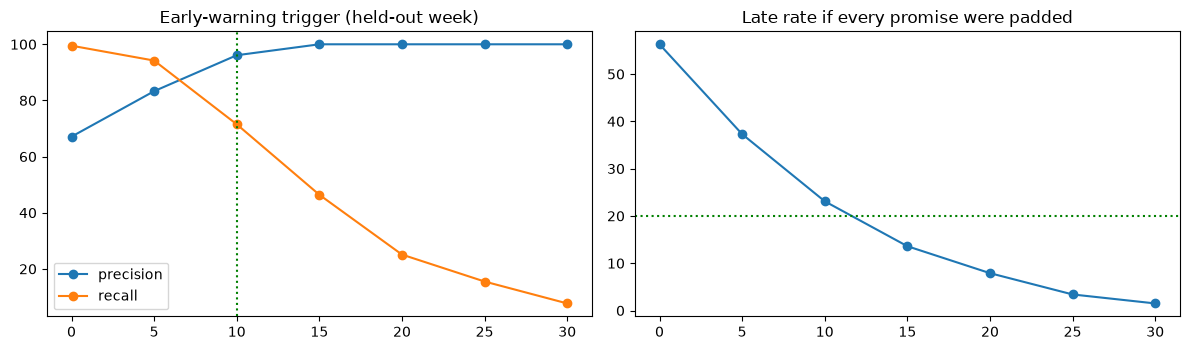

In [8]:
import matplotlib.pyplot as plt
t = ins.tables["early_warning_backtest"].query("split == 'test'")
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(t.grace_min, t.precision_pct, marker="o", label="precision"); ax[0].plot(t.grace_min, t.recall_pct, marker="o", label="recall")
ax[0].axvline(ins.headline["early_warning"]["chosen_grace_min"], ls=":", c="g"); ax[0].set_title("Early-warning trigger (held-out week)"); ax[0].legend()
e = ins.tables["eta_calibration"].query("eta_model_version == 'all versions'")
ax[1].plot(e.padding_min, e.late_rate_pct, marker="o"); ax[1].axhline(100 - cfg.target_on_time_rate_pct, ls=":", c="g"); ax[1].set_title("Late rate if every promise were padded")
plt.tight_layout(); plt.show()

## 8 · The gate — publish or not?

In [9]:
mr.checks.extend(ledger_checks)
gate = build_gate(ingestion, results, mr, cfg)
display(pd.DataFrame(gate["checks"])[["check", "status", "evidence"]])
print(gate["overall_status"], "->", gate["publish_decision"])

,check,status,evidence
0,Retrieval completeness,PASS,"API: 1600 records / expected 1600 in 16 pages, retries=2, mode=live; client ..."
1,Business grain (one row per order),WARN,raw duplicate rows removed by cleaning: 3 (corrected; conflicting copies kep...
2,Timestamp chronology & completeness,WARN,TS-00=0; TS-01=4; TS-02=5; TS-03=0; TS-04=37; TS-05=0
3,KPI definition ownership,UNKNOWN,no canonical KPI owner documented; 4 stakeholder definitions found: VP Opera...
4,Category semantics,WARN,"ST-01: fixes=5, unexpected={}; ST-02: fixes=3, unexpected={}; ST-04: fixes=2..."
5,Cross-source mapping,WARN,"coverage %: ID-02=100.0, ID-03=99.81, ID-04=99.81, ID-05=98.51, ID-06=100.0,..."
6,Freshness (restaurant status feed),WARN,status rows joined=500 covering 500 of 1600 orders (31.2%); ready/handed_off...
7,Metric sanity & independent checks,PASS,11 checks passed
8,Independent cross-check (observed weather vs client label),WARN,hours covered=100.0%; agreement=52.6%; Cohen's kappa=0.009; mean observed mm...


WARN -> PUBLISH WITH CAVEATS: late delivery rate = 56.33% of 1486 validated deliveries (historical definition: 56.39%). State the definition, the excluded orders and the unresolved owner questions next to the number.
